In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("D:\Power BI\Movie_Review_Sentiment_Analysis\Dataset\IMDB Dataset.csv")

In [3]:
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [7]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [8]:
df['clean_review'] = df['review'].str.lower()
df[['review','clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production. <br /><br />the...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","petter mattei's ""love in the time of money"" is..."


In [9]:
import string

df['clean_review'] = df['clean_review'].apply(
    lambda x: x.translate(str.maketrans('','',string.punctuation))
)

In [10]:
df[['review','clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production br br the filmin...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...


In [11]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\harsh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


In [13]:
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [14]:
df['clean_review'] = df['clean_review'].apply(remove_stopwords)

In [15]:
df[['review','clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching 1 oz episode ...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


The review text was cleaned by converting all text to lowercase, removing punctuation marks, and eliminating common stopwords. This preprocessing improves text quality and prepares the data for sentiment analysis.

In [16]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [19]:
positive_reviews = df[df['sentiment'] == 'positive']
positive_reviews[['clean_review']].head(5)

,clean_review
0,one reviewers mentioned watching 1 oz episode ...
1,wonderful little production br br filming tech...
2,thought wonderful way spend time hot summer we...
4,petter matteis love time money visually stunni...
5,probably alltime favorite movie story selfless...


In [20]:
negative_reviews = df[df['sentiment'] == 'negative']
negative_reviews[['clean_review']].head(5)

,clean_review
3,basically theres family little boy jake thinks...
7,show amazing fresh innovative idea 70s first a...
8,encouraged positive comments film looking forw...
10,phil alien one quirky films humour based aroun...
11,saw movie 12 came recall scariest scene big bi...


In [21]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [22]:
from textblob import TextBlob

In [31]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "positive"
    elif polarity < 0:
        return "negative"
    else:
        return "neutral"

In [32]:
get_sentiment("This movie was amazing")

'positive'

In [33]:
df['predicted_sentiment']=df['clean_review'].apply(get_sentiment)

In [35]:
df[['clean_review','predicted_sentiment']].head()

,clean_review,predicted_sentiment
0,one reviewers mentioned watching 1 oz episode ...,positive
1,wonderful little production br br filming tech...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically theres family little boy jake thinks...,positive
4,petter matteis love time money visually stunni...,positive


In [36]:
df['predicted_sentiment'].value_counts()

predicted_sentiment
positive    36646
negative    13311
neutral        43
Name: count, dtype: int64

## Sentiment Observation
Sentiment analysis was performed using TextBlob. Out of 50,000 movie reviews, 36,646 were classified as positive, 13,311 as negative, and 43 are neutral.

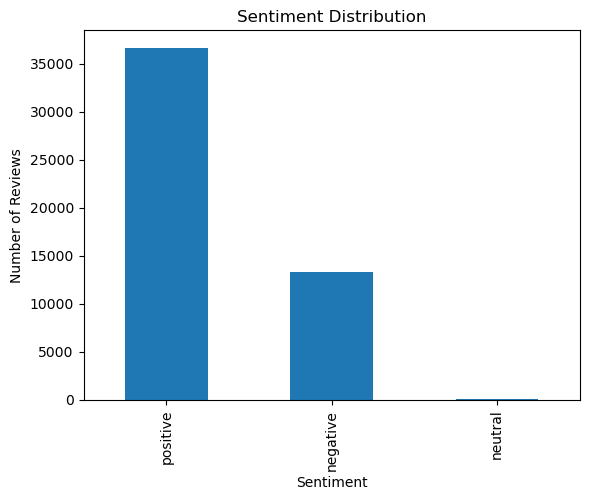

In [38]:
df['predicted_sentiment'].value_counts().plot(kind = 'bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

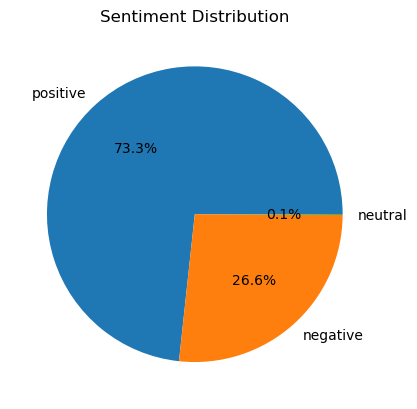

In [40]:
df['predicted_sentiment'].value_counts().plot(
    kind ='pie',
    autopct = '%1.1f%%'
)
plt.title('Sentiment Distribution')
plt.ylabel('')

plt.show()

In [43]:
positive_reviews = df[df['predicted_sentiment'] =='positive']
positive_reviews[['clean_review']].head(3)

,clean_review
0,one reviewers mentioned watching 1 oz episode ...
1,wonderful little production br br filming tech...
2,thought wonderful way spend time hot summer we...


In [44]:
negtive_reviews = df[df['predicted_sentiment'] == 'negative']
negative_reviews[['clean_review']].head(3)
    

,clean_review
3,basically theres family little boy jake thinks...
7,show amazing fresh innovative idea 70s first a...
8,encouraged positive comments film looking forw...


In [45]:
df.to_csv('Final_IMDB_Analysis.csv', index = False)